# Experiments increasing the resolution of the chromatin deconvolution
February 12, 2024

In this notebook, we will deconvolve the chromatin, and identify the limits to increasing the resolution of the deconvolution. The timing of the model should scale proportional to the input size.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

gene_name = 'CLB2'
config1 = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_gene(gene_name, 1)

Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)


In [173]:
y_bins = np.arange(0, 225, 10)
x_bin_size = 10
promoter_bins = 24
gene_body_bins = 40


chromatin_model.define_histogram_bins(x_bin_size, promoter_bins, gene_body_bins, 
    y_bins=y_bins)
chromatin_model.create_bins_per_all_sample()


The histogram shape around the TSS is: (22, 65)


In [174]:
chromatin_model.create_deconvolution_matrices(False)

The shape of the flattened grid to be deconvolved is: (16, 1430)


In [175]:
chromatin_model.smooth_bins()

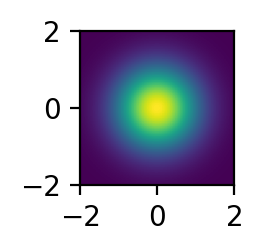

In [233]:
g_kernel = create_2d_gaussian_kernel(k_size=60, sigma=0.75, plot=True)

In [ ]:
from scipy.ndimage import zoom
from scipy.signal import convolve2d
from src.preprocessing import create_2d_gaussian_kernel

xbins = np.arange(*chromatin_model.mnase_span)
ybins = np.arange(0, 225)

n = len(chromatin_model.timepoints)
output_shape = (22, 65)
resized_data = np.zeros((n, output_shape[0], output_shape[1]))

for i in range(n):

    sample = chromatin_model.timepoints[i]

    plotting_reads, hist, \
        x_edges, y_edges = chromatin_model.compute_bin_counts_sample(sample, xbins, ybins)
    hist = hist.T

    smoothed_img = convolve2d(hist, g_kernel, mode='same')

    zoom_factors = (output_shape[0] / smoothed_img.shape[0], 
                    output_shape[1] / smoothed_img.shape[1])
    resized_matrix = zoom(smoothed_img, zoom_factors, order=3)  # cubic spline interpolation
    
    resized_data[i] = resized_matrix

resized_data = resized_data*100.

In [ ]:
plt.figure(figsize=(9, 1))

vmax = 0.25

plt.subplot(1, 3, 1)
plt.imshow(hist, aspect='auto', cmap='magma_r', vmax=vmax, origin='lower')

plt.subplot(1, 3, 2)
plt.imshow(smoothed_img, aspect='auto', cmap='magma_r', vmax=vmax, origin='lower')

plt.subplot(1, 3, 3)
plt.imshow(resized_data[-1], aspect='auto', cmap='magma_r', vmax=vmax*100, origin='lower')

(array([2.1518e+04, 9.5600e+02, 2.6000e+02, 8.7000e+01, 3.2000e+01,
        1.1000e+01, 7.0000e+00, 5.0000e+00, 3.0000e+00, 1.0000e+00]),
 array([-1.26467345e-03,  4.17401077e+00,  8.34928622e+00,  1.25245617e+01,
         1.66998371e+01,  2.08751126e+01,  2.50503880e+01,  2.92256634e+01,
         3.34009389e+01,  3.75762143e+01,  4.17514898e+01]),
 <BarContainer object of 10 artists>)

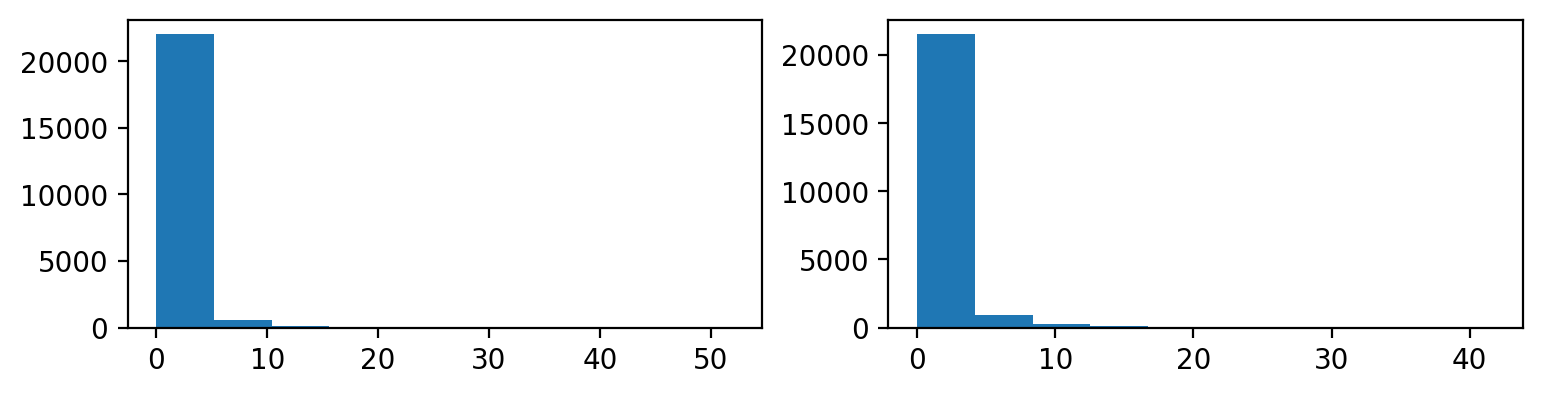

In [229]:
plt.figure(figsize=(9, 2))
plt.subplot(1, 2, 1)
plt.hist(chromatin_model.unsmoothed_all_hists.flatten())

plt.subplot(1, 2, 2)
plt.hist(resized_data.flatten())

In [182]:
#fig = chromatin_model.plot_raw_bins(vmax=20)

In [216]:
# Let's test our new resized data with the deconvolution:
chromatin_model.all_hists = resized_data

In [217]:
# It's possible we will want to increase the value of the counts on the resized data
# They will probably be very small (on the scale of 0-1)
# When previously, we were deconvolving values from 0-100 (dependent on the size
# of the bins)

In [218]:
chromatin_model.gamma = 0.001
chromatin_model.deconvolve(solver='MOSEK', verbose=True)

                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 12 04:31:42 PM: Your problem has 324610 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 12 04:31:42 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 12 04:31:42 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 12 04:31:42 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 12 04:31:42 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 12 04:31:42 PM: Compiling problem (target solver=MOSEK).

(CVXPY) Feb 12 04:34:22 PM: 26  9.4e-03  1.9e-02  7.5e-04  4.19e-01   7.074551076e+03   7.074554886e+03   9.4e-03  61.13 
(CVXPY) Feb 12 04:34:23 PM: 27  6.9e-03  1.4e-02  5.0e-04  4.02e-01   7.054700353e+03   7.054703478e+03   6.9e-03  62.14 
(CVXPY) Feb 12 04:34:24 PM: 28  5.6e-03  1.1e-02  3.9e-04  3.81e-01   7.041453155e+03   7.041455900e+03   5.6e-03  63.04 
(CVXPY) Feb 12 04:34:25 PM: 29  5.0e-03  1.0e-02  3.4e-04  3.73e-01   7.034441629e+03   7.034444205e+03   5.0e-03  64.04 
(CVXPY) Feb 12 04:34:26 PM: 30  4.3e-03  8.6e-03  2.8e-04  3.67e-01   7.024477952e+03   7.024480305e+03   4.3e-03  65.37 
(CVXPY) Feb 12 04:34:27 PM: 31  3.7e-03  7.5e-03  2.3e-04  3.54e-01   7.014633977e+03   7.014636137e+03   3.7e-03  66.22 
(CVXPY) Feb 12 04:34:28 PM: 32  3.5e-03  6.9e-03  2.1e-04  3.42e-01   7.009097040e+03   7.009099103e+03   3.5e-03  67.00 
(CVXPY) Feb 12 04:34:29 PM: 33  3.3e-03  6.5e-03  2.0e-04  3.37e-01   7.004938301e+03   7.004940293e+03   3.3e-03  67.72 
(CVXPY) Feb 12 04:34:30 

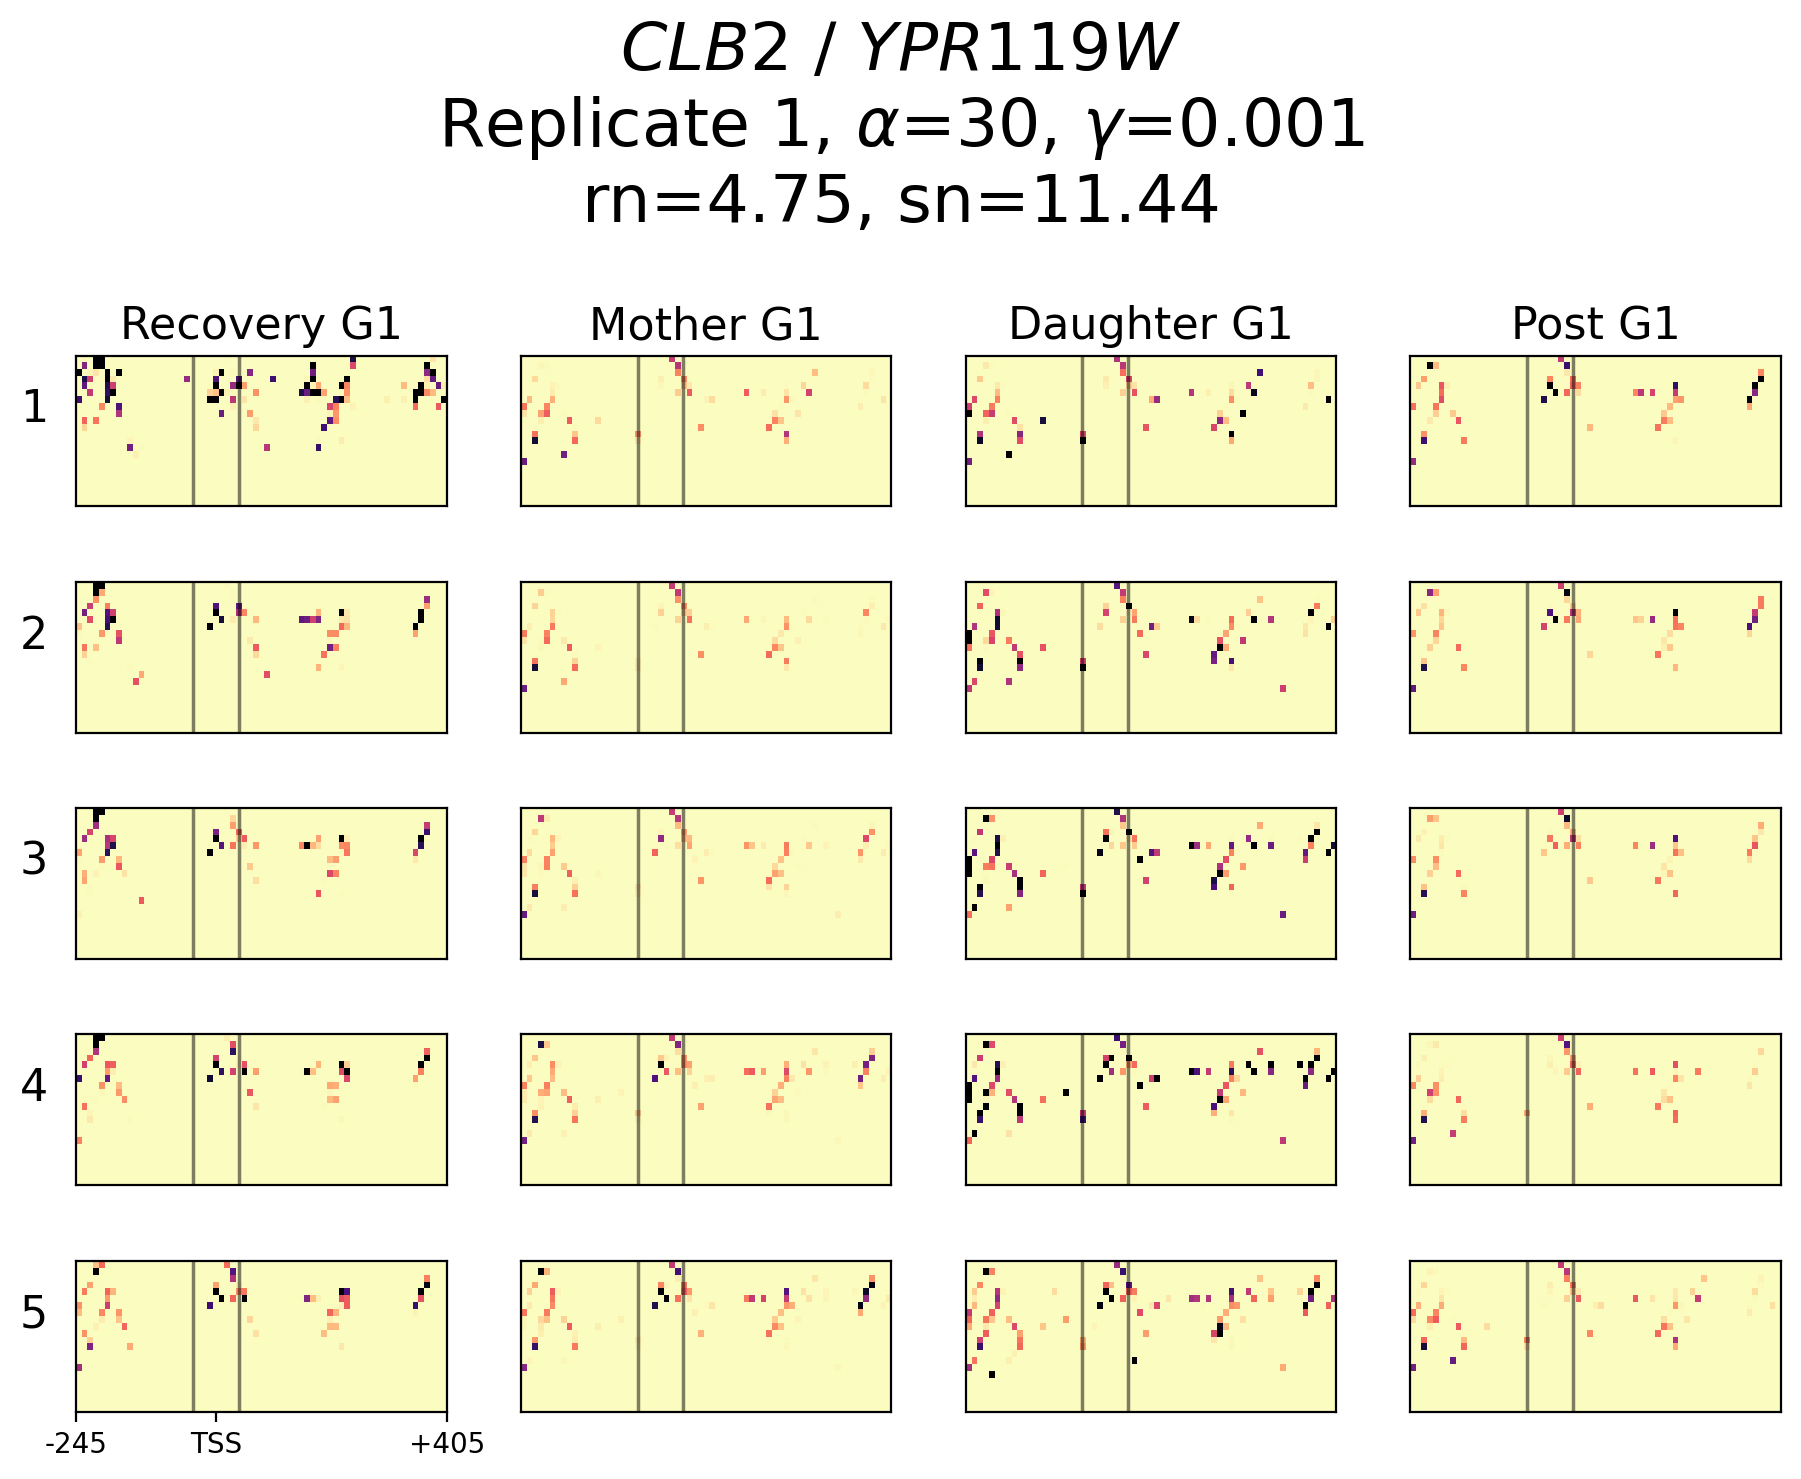

In [221]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=10)

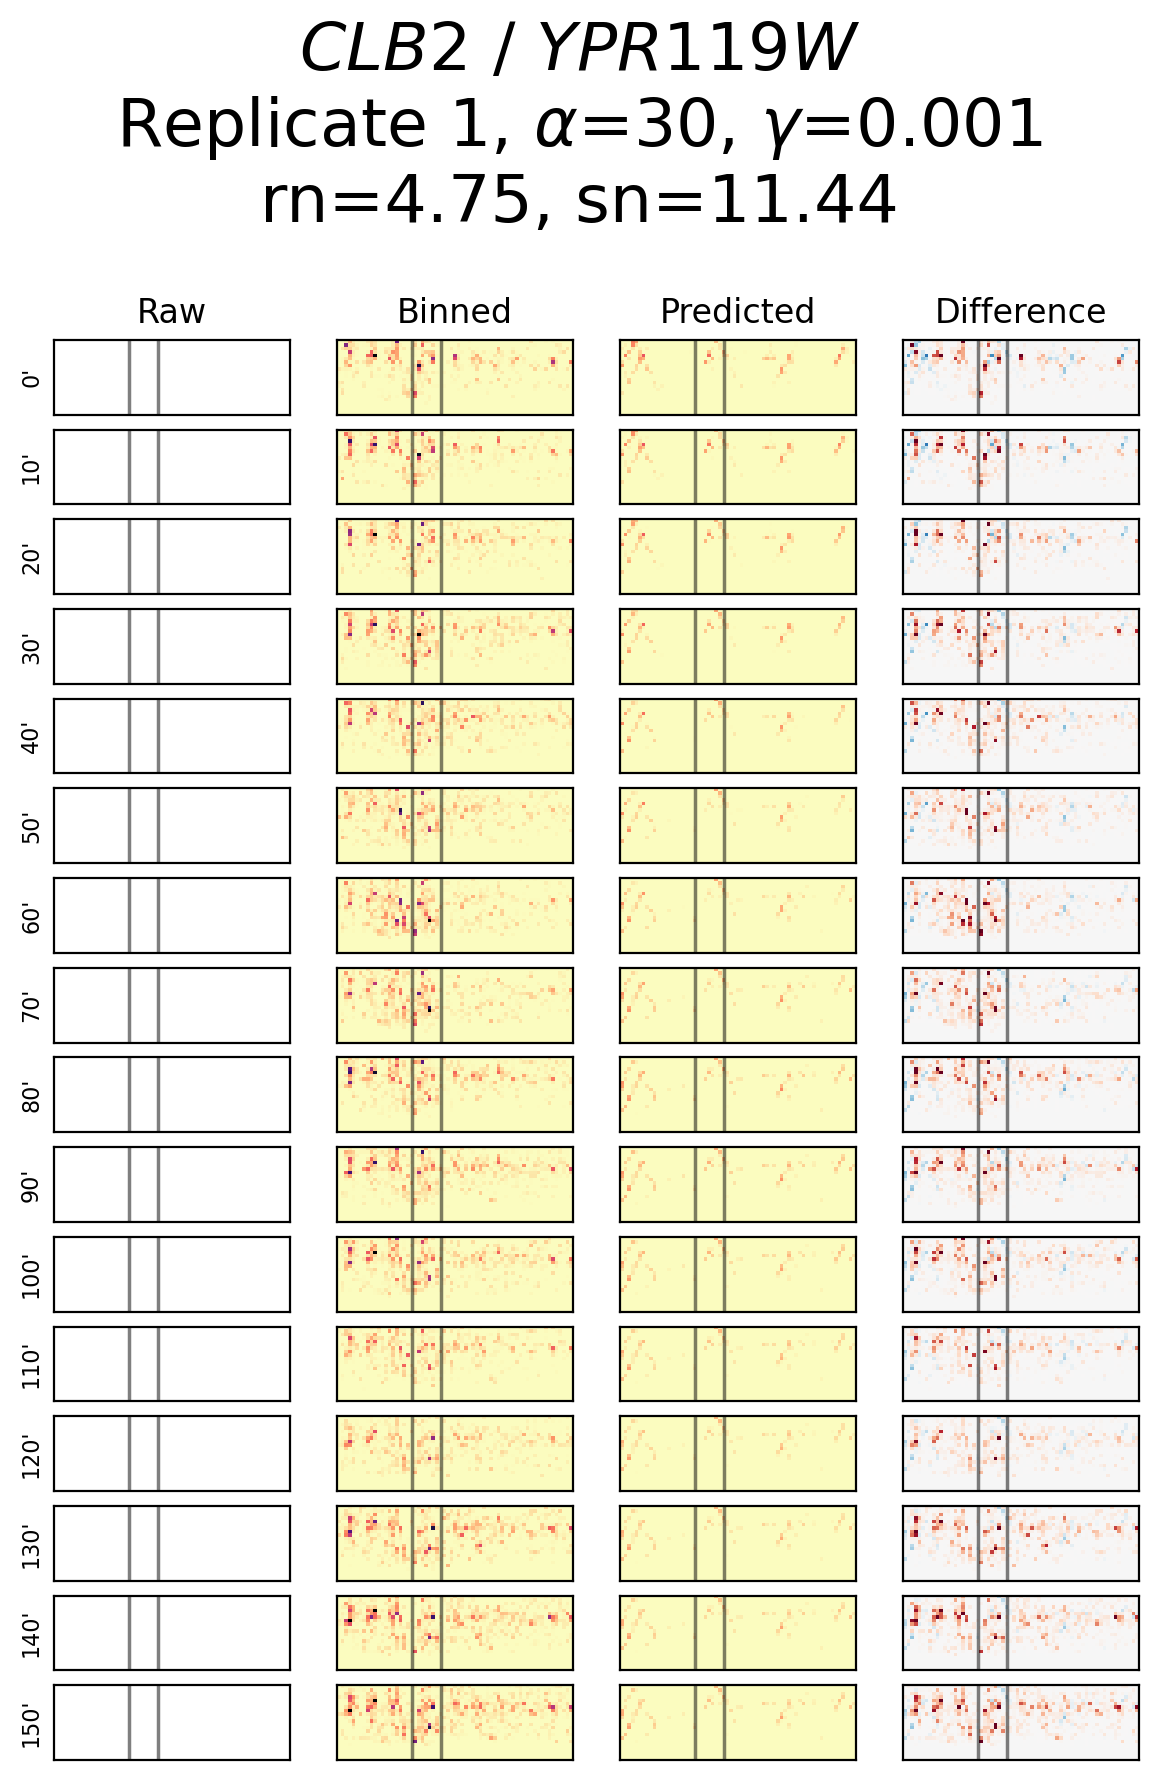

In [223]:
fig = chromatin_model.plot_prediction_comparison(vmax=50)